# Основное обучение

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [71]:
df_train = pd.read_csv('../data/processed/train_cleaned.csv')
df_test = pd.read_csv('../data/processed/test_cleaned.csv')

target_col = 'IsFraud' if 'IsFraud' in df_train.columns else 'isfraud'

print("ЭТАП 1: Генерируем сглаженный Target Encoding (Bayesian Smoothing)")
prior_weight = 10 
global_mean = df_train[target_col].mean()

rec_agg = df_train.groupby('RecipientID')[target_col].agg(['sum', 'count'])
smoothed_rec = (rec_agg['sum'] + prior_weight * global_mean) / (rec_agg['count'] + prior_weight)
df_train['recipient_fraud_rate'] = df_train['RecipientID'].map(smoothed_rec).fillna(global_mean)
df_test['recipient_fraud_rate'] = df_test['RecipientID'].map(smoothed_rec).fillna(global_mean)

user_agg = df_train.groupby('UserID')[target_col].agg(['sum', 'count'])
smoothed_user = (user_agg['sum'] + prior_weight * global_mean) / (user_agg['count'] + prior_weight)
df_train['user_fraud_rate'] = df_train['UserID'].map(smoothed_user).fillna(global_mean)
df_test['user_fraud_rate'] = df_test['UserID'].map(smoothed_user).fillna(global_mean)

print("ЭТАП 2: Удаляем мусорные и шумовые признаки (Feature Selection)")
toxic_and_noisy_cols = [
    target_col, 'UserID', 'EventTime', 'Currency', 'Unnamed: 0', 'RecipientID', 'MerchantType',
    'unique_recipients_cum', 'unique_merchants_cum', 'total_trans_cum',
    'trans_cum_sum', 'trans_cum_count', 'p2p_sent_cum_sum', 'p2p_sent_cum_count',
    'prop_Entertainment', 'prop_Housekeeping', 'is_new_recipient', 'recipient_diversity_ratio' 
]

X_train_full = df_train.drop(columns=[col for col in toxic_and_noisy_cols if col in df_train.columns])
y_train_full = df_train[target_col]

X_test = df_test.drop(columns=[col for col in toxic_and_noisy_cols if col in df_test.columns])
y_test = df_test[target_col]

for df_tmp in [X_train_full, X_test]:
    if 'hour' in df_tmp.columns: df_tmp['hour'] = df_tmp['hour'].astype(float)
    if 'day_of_week' in df_tmp.columns: df_tmp['day_of_week'] = df_tmp['day_of_week'].astype(float)

split_idx = int(len(X_train_full) * 0.8)
X_train = X_train_full.iloc[:split_idx]
y_train = y_train_full.iloc[:split_idx]
X_val = X_train_full.iloc[split_idx:]
y_val = y_train_full.iloc[split_idx:]

cv_strategy = TimeSeriesSplit(n_splits=3)

print(f"Обучение: {X_train.shape[0]} строк | Валидация: {X_val.shape[0]} строк")
print(f"Осталось {X_train.shape[1]} информативных признаков: {list(X_train.columns)}")

ЭТАП 1: Генерируем сглаженный Target Encoding (Bayesian Smoothing)
ЭТАП 2: Удаляем мусорные и шумовые признаки (Feature Selection)
Обучение: 1578283 строк | Валидация: 394571 строк
Осталось 19 информативных признаков: ['Amount', 'time_since_last_p2p', 'p2p_count_1h', 'p2p_sum_1h', 'p2p_count_24h', 'p2p_sum_24h', 'hour', 'day_of_week', 'time_diff_p2p', 'p2p_amt_to_mean_3', 'time_diff_trans', 'trans_amt_to_mean_3', 'prop_Education', 'prop_Financial Institution', 'prop_Groceries', 'prop_Transport', 'is_cold_user', 'recipient_fraud_rate', 'user_fraud_rate']


In [72]:
model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    scale_pos_weight=100,      
    loss_function='Logloss',           
    eval_metric='Logloss',
    random_state=42,
    task_type='GPU',
    devices='0',
    early_stopping_rounds=100           
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=50,
    plot=True
)
print(f"\nУспешно обучено деревьев: {model.tree_count_}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.4595964	test: 0.4591627	best: 0.4591627 (0)	total: 36.9ms	remaining: 36.9s
50:	learn: 0.0000958	test: 0.0002121	best: 0.0001966 (44)	total: 831ms	remaining: 15.5s
100:	learn: 0.0000680	test: 0.0002394	best: 0.0001966 (44)	total: 1.61s	remaining: 14.4s
bestTest = 0.0001965884555
bestIteration = 44
Shrink model to first 45 iterations.

Успешно обучено деревьев: 45


--- РЕЗУЛЬТАТЫ НА ОТЛОЖЕННОМ ТЕСТЕ ---
ROC-AUC:           0.9947
Average Precision: 0.6413

--- ВЫПОЛНЕНИЕ БИЗНЕС-ТРЕБОВАНИЙ ---
Оптимальный порог: 0.0021
Precision:         0.6692
Recall:            0.7225


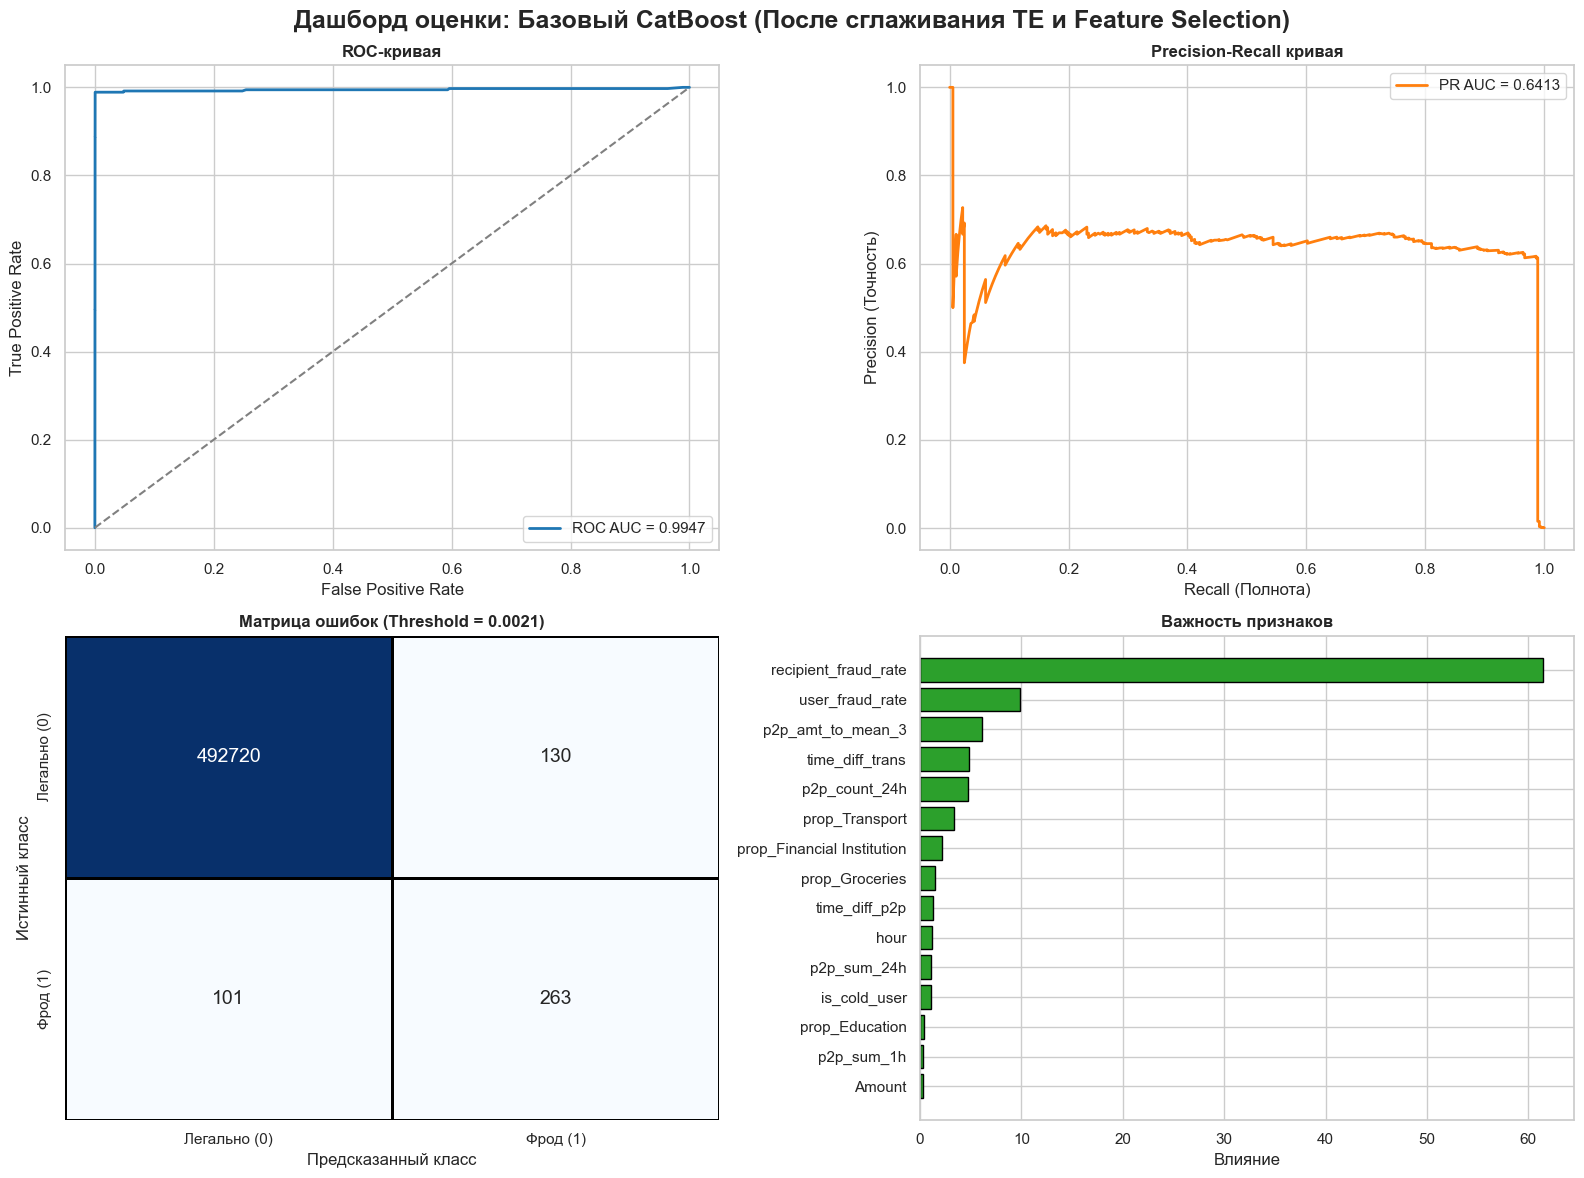

In [ ]:
# Рассчитываем вероятности на тесте для базовой модели
y_probs = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

print("--- РЕЗУЛЬТАТЫ НА ОТЛОЖЕННОМ ТЕСТЕ ---")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Average Precision: {ap_score:.4f}")

# Подбор порога под Recall >= 70%
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
valid_indices = np.where(recalls >= 0.70)[0]

if len(valid_indices) > 0:
    best_index = valid_indices[np.argmax(precisions[valid_indices])]
    optimal_threshold = thresholds[best_index]
    print("\n--- ВЫПОЛНЕНИЕ БИЗНЕС-ТРЕБОВАНИЙ ---")
    print(f"Оптимальный порог: {optimal_threshold:.4f}")
    print(f"Precision:         {precisions[best_index]:.4f}")
    print(f"Recall:            {recalls[best_index]:.4f}")
else:
    optimal_threshold = 0.5
    print("\nМодель не смогла достичь Recall >= 70%. Использован порог 0.5")

plot_any_model_evaluation(
    y_true=y_test, 
    y_pred_proba=y_probs, 
    title_name="Базовый CatBoost (После сглаживания TE и Feature Selection)", 
    threshold=optimal_threshold,
    eval_model=model,
    X_train_df=X_train
)

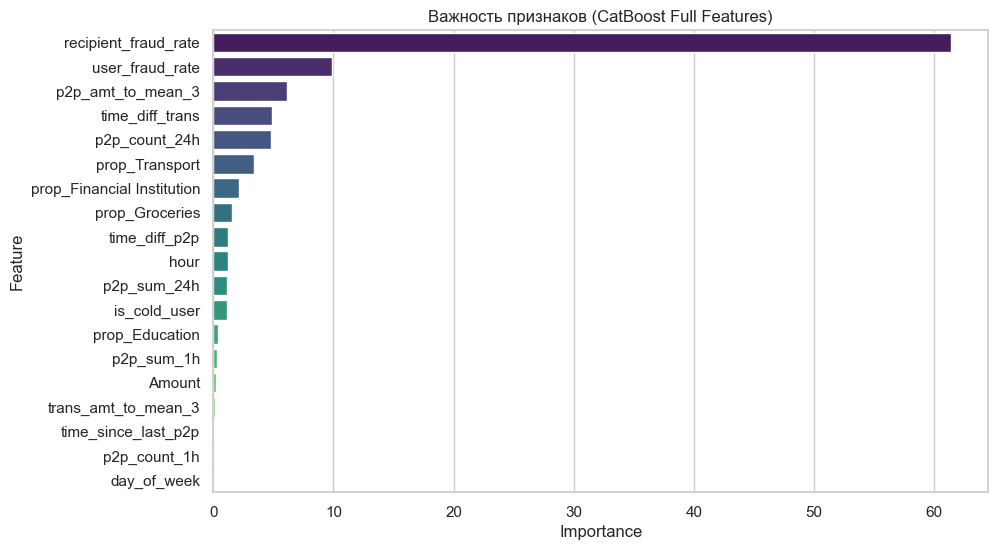

Модель успешно сохранена: ../models/catboost_fraud_model_cv.cbm


In [74]:
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, hue='Feature', legend=False, palette='viridis')
plt.title(f"Важность признаков (CatBoost Full Features)")
plt.show()

model_path = '../models/catboost_fraud_model_cv.cbm'
model.save_model(model_path)
print(f"Модель успешно сохранена: {model_path}")

# Эксперименты

In [75]:
from sklearn.metrics import roc_curve, confusion_matrix

fig_bg_color = '#ffffff'

def plot_any_model_evaluation(y_true, y_pred_proba, title_name, threshold=0.5, eval_model=None, X_train_df=None):
    """
    Универсальный дашборд с защитой от изменения размерности (OHE/Pipelines).
    """
    has_importance = eval_model is not None and (
        hasattr(eval_model, "feature_importances_") or 
        hasattr(eval_model, "coef_") or 
        (hasattr(eval_model, "get_feature_importance") and callable(getattr(eval_model, "get_feature_importance")))
    )
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=fig_bg_color)
    fig.suptitle(f'Дашборд оценки: {title_name}', fontsize=18, fontweight='bold')

    # 1. ROC-кривая
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc_val = roc_auc_score(y_true, y_pred_proba)
    axes[0, 0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC AUC = {roc_auc_val:.4f}')
    axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[0, 0].set_title('ROC-кривая', fontweight='bold')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].legend(loc='lower right')

    # 2. Precision-Recall кривая
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    axes[0, 1].plot(recall, precision, color='#ff7f0e', lw=2, label=f'PR AUC = {pr_auc:.4f}')
    axes[0, 1].set_title('Precision-Recall кривая', fontweight='bold')
    axes[0, 1].set_xlabel('Recall (Полнота)')
    axes[0, 1].set_ylabel('Precision (Точность)')
    axes[0, 1].legend(loc='upper right')

    # 3. Матрица ошибок
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], linewidths=1, linecolor='black', cbar=False, annot_kws={"size": 14})
    axes[1, 0].set_title(f'Матрица ошибок (Threshold = {threshold:.4f})', fontweight='bold')
    axes[1, 0].set_xlabel('Предсказанный класс')
    axes[1, 0].set_ylabel('Истинный класс')
    axes[1, 0].xaxis.set_ticklabels(['Легально (0)', 'Фрод (1)'])
    axes[1, 0].yaxis.set_ticklabels(['Легально (0)', 'Фрод (1)'])

    # 4. Важность признаков / Распределение вероятностей
    if has_importance:
        if hasattr(eval_model, "feature_importances_"):
            importances = eval_model.feature_importances_
        elif hasattr(eval_model, "coef_"):
            importances = np.abs(eval_model.coef_[0]) if eval_model.coef_.ndim > 1 else np.abs(eval_model.coef_)
        else:
            importances = eval_model.get_feature_importance()

        if X_train_df is not None and len(importances) == len(X_train_df.columns):
            feature_names = np.array(X_train_df.columns)
        elif hasattr(eval_model, "feature_names_") and eval_model.feature_names_ is not None:
            feature_names = np.array(eval_model.feature_names_)
        else:
            feature_names = np.array([f"Feature {i} (Transformed)" for i in range(len(importances))])
            
        idx = np.argsort(importances)
        top_n = min(15, len(importances))
        
        axes[1, 1].barh(range(top_n), importances[idx][-top_n:], color='#2ca02c', edgecolor='black')
        axes[1, 1].set_yticks(range(top_n))
        axes[1, 1].set_yticklabels(feature_names[idx][-top_n:])
        axes[1, 1].set_title('Важность признаков', fontweight='bold')
        axes[1, 1].set_xlabel('Влияние')
    else:
        axes[1, 1].hist(y_pred_proba[y_true == 0], bins=50, alpha=0.5, color='blue', label='Легальные', density=True)
        axes[1, 1].hist(y_pred_proba[y_true == 1], bins=50, alpha=0.5, color='red', label='Фрод', density=True)
        axes[1, 1].set_title('Распределение предсказанных вероятностей риска', fontweight='bold')
        axes[1, 1].set_xlabel('Вероятность фрода')
        axes[1, 1].set_ylabel('Плотность (Log Scale)')
        axes[1, 1].set_yscale('log')
        axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

In [76]:
print("ЭТАП 1: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (One-Hot Encoding + GridSearch)")

cat_features = ['hour', 'day_of_week']
num_features = [col for col in X_train.columns if col not in cat_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

param_grid_lr = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}

grid_lr = GridSearchCV(
    estimator=pipeline_lr, 
    param_grid=param_grid_lr, 
    cv=cv_strategy,
    scoring='average_precision', 
    verbose=1,
    n_jobs=-1
)

print("Начинаем подбор гиперпараметров для LogReg...")
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
y_probs_lr_best = best_lr.predict_proba(X_test)[:, 1]

print(f"\nЛучшие параметры LogReg (OHE): {grid_lr.best_params_}")
print(f"LogReg ROC-AUC на тесте: {roc_auc_score(y_test, y_probs_lr_best):.4f}")
print(f"LogReg PR-AUC на тесте:  {average_precision_score(y_test, y_probs_lr_best):.4f}")

ЭТАП 1: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (One-Hot Encoding + GridSearch)
Начинаем подбор гиперпараметров для LogReg...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшие параметры LogReg (OHE): {'classifier__C': 0.01}
LogReg ROC-AUC на тесте: 0.9954
LogReg PR-AUC на тесте:  0.7645


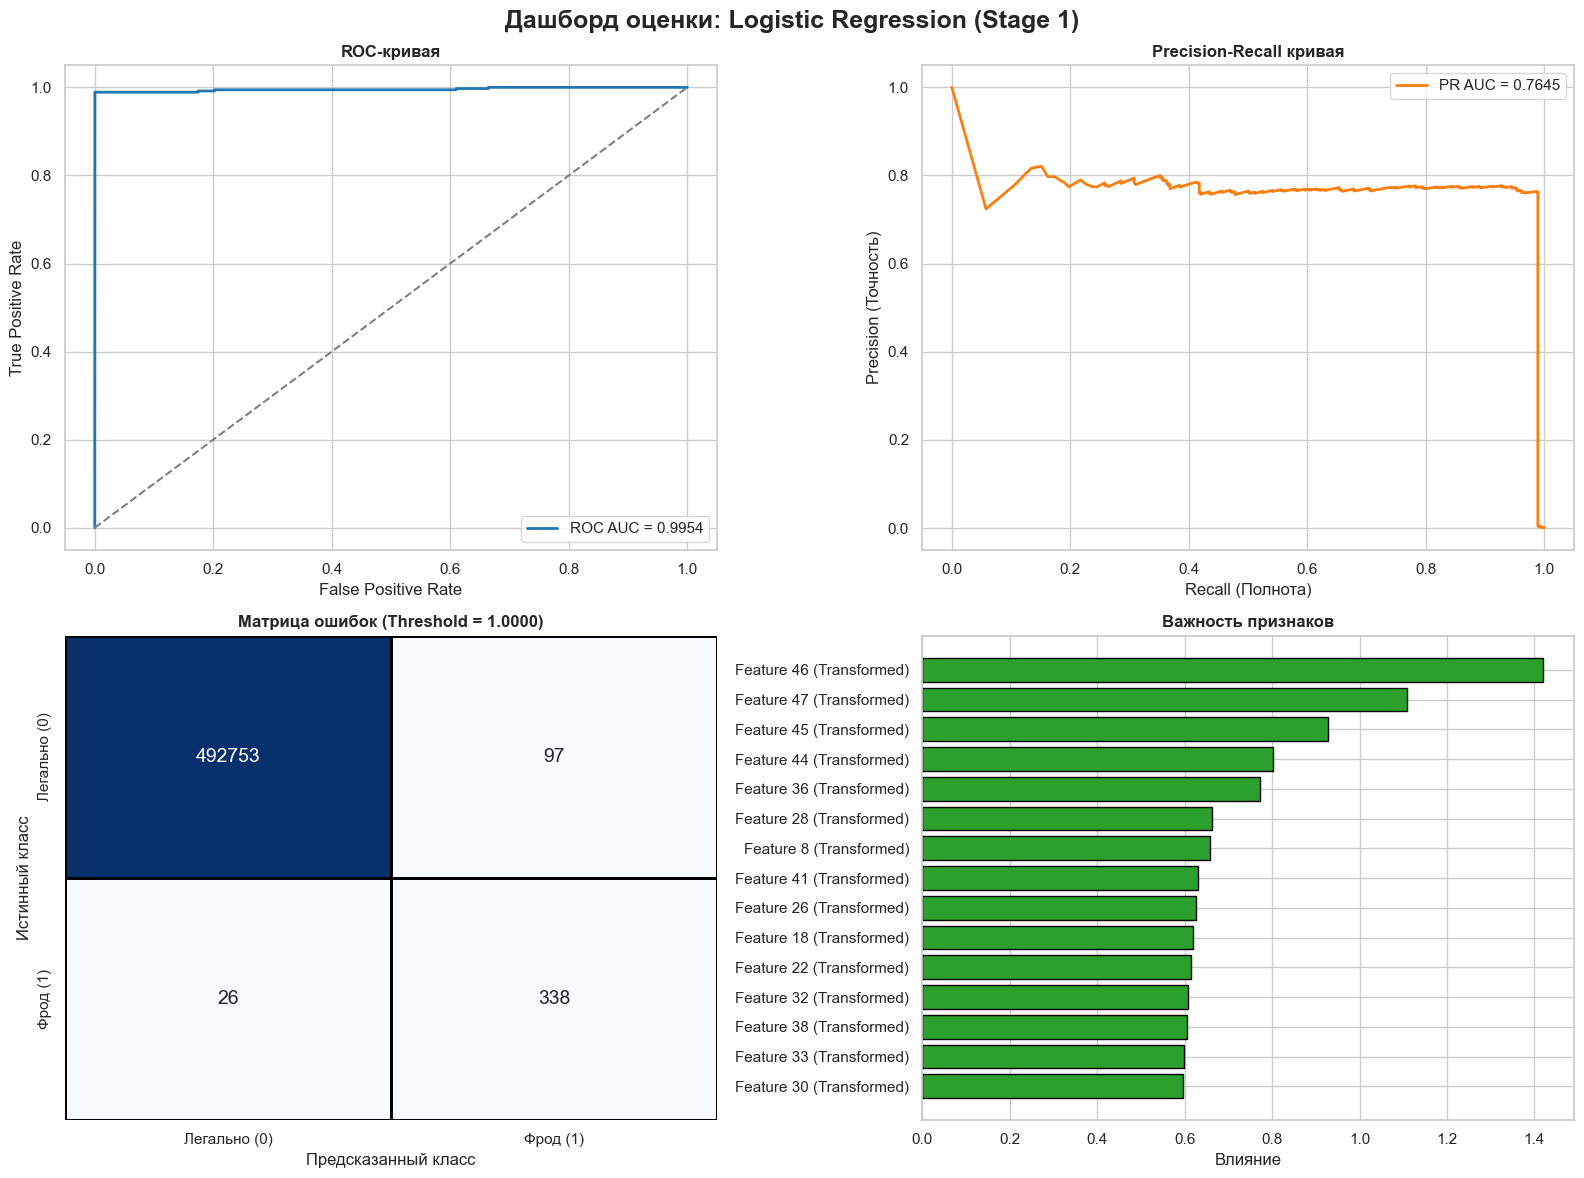

In [77]:
precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_test, y_probs_lr_best)
valid_lr = np.where(recalls_lr >= 0.70)[0]
optimal_threshold_lr = thresholds_lr[valid_lr[np.argmax(precisions_lr[valid_lr])]] if len(valid_lr) > 0 else 0.5

plot_any_model_evaluation(
    y_true=y_test, 
    y_pred_proba=y_probs_lr_best, 
    title_name="Logistic Regression (Stage 1)", 
    threshold=optimal_threshold_lr,
    eval_model=best_lr.named_steps['classifier'],
    X_train_df=X_train
)

In [78]:
print("\nЭТАП 2: LightGBM (Встроенная обработка категорий + GridSearch)")

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype(int).astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype(int).astype('category')

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

lgbm_base = lgb.LGBMClassifier(scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, verbose=-1)

param_grid_lgb = {
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.1],
    'n_estimators': [200, 500]
}

grid_lgb = GridSearchCV(
    estimator=lgbm_base, 
    param_grid=param_grid_lgb, 
    cv=cv_strategy,
    scoring='average_precision', 
    verbose=1,
    n_jobs=1 
)

print("Начинаем подбор гиперпараметров для LightGBM...")
grid_lgb.fit(X_train_lgb, y_train, categorical_feature=cat_features)

best_lgb = grid_lgb.best_estimator_
y_probs_lgb_best = best_lgb.predict_proba(X_test_lgb)[:, 1]

print(f"\nЛучшие параметры LightGBM: {grid_lgb.best_params_}")
print(f"LightGBM ROC-AUC на тесте: {roc_auc_score(y_test, y_probs_lgb_best):.4f}")
print(f"LightGBM PR-AUC на тесте:  {average_precision_score(y_test, y_probs_lgb_best):.4f}")


ЭТАП 2: LightGBM (Встроенная обработка категорий + GridSearch)
Начинаем подбор гиперпараметров для LightGBM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Лучшие параметры LightGBM: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
LightGBM ROC-AUC на тесте: 0.4841
LightGBM PR-AUC на тесте:  0.0190


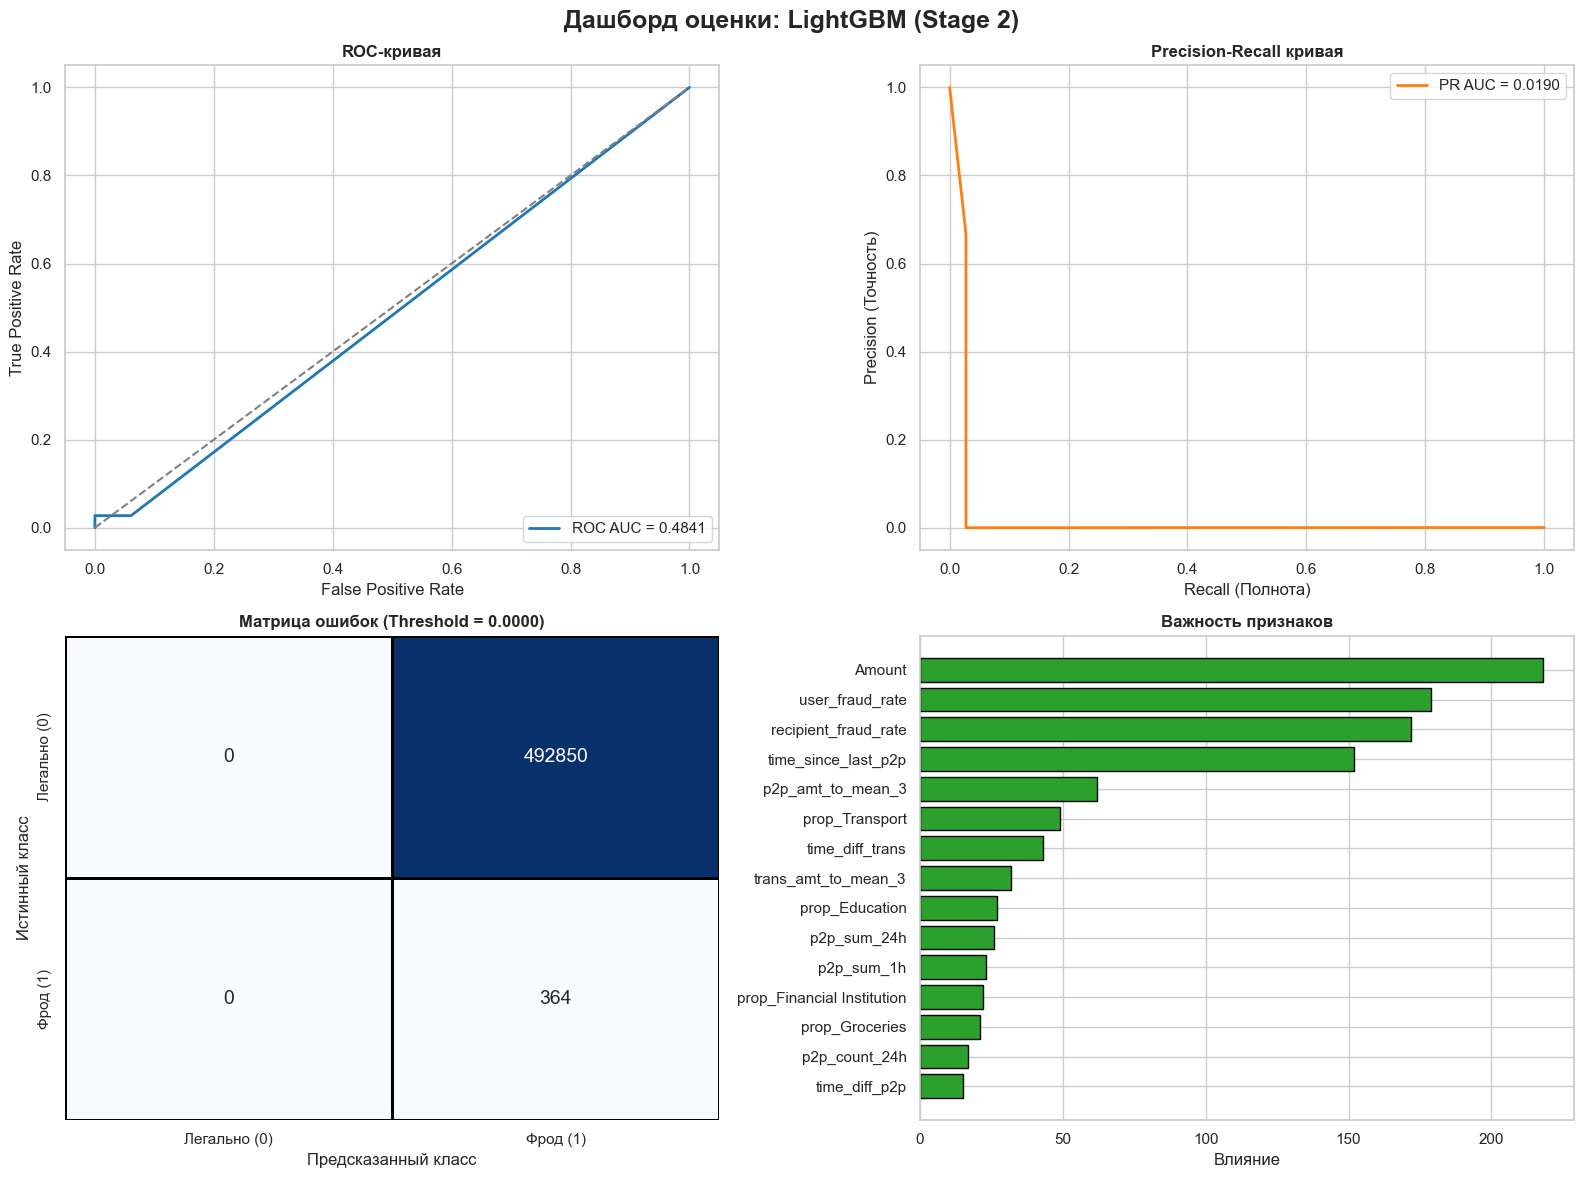

In [79]:
precisions_lgb, recalls_lgb, thresholds_lgb = precision_recall_curve(y_test, y_probs_lgb_best)
valid_lgb = np.where(recalls_lgb >= 0.70)[0]
optimal_threshold_lgb = thresholds_lgb[valid_lgb[np.argmax(precisions_lgb[valid_lgb])]] if len(valid_lgb) > 0 else 0.5

plot_any_model_evaluation(
    y_true=y_test, 
    y_pred_proba=y_probs_lgb_best, 
    title_name="LightGBM (Stage 2)", 
    threshold=optimal_threshold_lgb,
    eval_model=best_lgb, 
    X_train_df=X_train_lgb
)

In [80]:
print("\nЭТАП 3: GridSearch НА ДАННЫХ С ТАРГЕТ-ЭНКОДИНГОМ")

# 1. Готовим данные с Target Encoding заново
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in cat_features:
    target_mean = y_train.groupby(X_train[col]).mean()
    X_train_enc[f'{col}_te'] = X_train[col].map(target_mean)
    X_test_enc[f'{col}_te'] = X_test[col].map(target_mean).fillna(y_train.mean())
    X_train_enc = X_train_enc.drop(columns=[col])
    X_test_enc = X_test_enc.drop(columns=[col])

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

# 2. Тюнинг LogReg на Target Encoding
print("\nНачинаем подбор для LogReg (Target Encoding)...")
param_grid_lr_te = {'C': [0.01, 0.1, 1.0, 10.0]}

grid_lr_te = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid_lr_te, cv=cv_strategy, scoring='average_precision', verbose=1, n_jobs=-1
)
grid_lr_te.fit(X_train_scaled, y_train)

best_lr_te = grid_lr_te.best_estimator_
y_probs_lr_te = best_lr_te.predict_proba(X_test_scaled)[:, 1]

print(f"Лучшие параметры LogReg (TE): {grid_lr_te.best_params_}")
print(f"LogReg (TE) ROC-AUC: {roc_auc_score(y_test, y_probs_lr_te):.4f}")
print(f"LogReg (TE) PR-AUC:  {average_precision_score(y_test, y_probs_lr_te):.4f}")

# 3. Тюнинг LightGBM на Target Encoding
print("\nНачинаем подбор для LightGBM (Target Encoding)...")

param_grid_lgb_te = {
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.1],
    'n_estimators': [200, 500]
}

grid_lgb_te = GridSearchCV(
    estimator=lgb.LGBMClassifier(scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, verbose=-1),
    param_grid=param_grid_lgb_te, cv=cv_strategy, scoring='average_precision', verbose=1, n_jobs=1
)
grid_lgb_te.fit(X_train_enc, y_train)

best_lgb_te = grid_lgb_te.best_estimator_
y_probs_lgb_te = best_lgb_te.predict_proba(X_test_enc)[:, 1]

print(f"Лучшие параметры LightGBM (TE): {grid_lgb_te.best_params_}")
print(f"LightGBM (TE) ROC-AUC: {roc_auc_score(y_test, y_probs_lgb_te):.4f}")
print(f"LightGBM (TE) PR-AUC:  {average_precision_score(y_test, y_probs_lgb_te):.4f}")


ЭТАП 3: GridSearch НА ДАННЫХ С ТАРГЕТ-ЭНКОДИНГОМ

Начинаем подбор для LogReg (Target Encoding)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры LogReg (TE): {'C': 0.01}
LogReg (TE) ROC-AUC: 0.9963
LogReg (TE) PR-AUC:  0.7579

Начинаем подбор для LightGBM (Target Encoding)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучшие параметры LightGBM (TE): {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200}
LightGBM (TE) ROC-AUC: 0.0522
LightGBM (TE) PR-AUC:  0.0165


In [83]:
print("ЭТАП 5: ТОНКАЯ НАСТРОЙКА ВЕСОВ (CatBoost)")

cb_manual = CatBoostClassifier(
    random_state=42,
    verbose=0,
    task_type='GPU', 
    devices='0'
)

param_grid_weights = {
    'class_weights': [[1, 1], [1, 10], [1, 35], [1, 100]],
    'depth': [6],
    'iterations': [500]
}

grid_weights = GridSearchCV(
    estimator=cb_manual,
    param_grid=param_grid_weights,
    cv=cv_strategy,
    scoring='average_precision',
    verbose=2
)

print("Начинаем подбор ручных весов на оптимальной глубине...")
grid_weights.fit(X_train, y_train)

best_cb_weights = grid_weights.best_estimator_
y_probs_weights = best_cb_weights.predict_proba(X_test)[:, 1]

print(f"\nЛучшие веса: {grid_weights.best_params_['class_weights']}")
print(f"CatBoost (Ручные веса) ROC-AUC: {roc_auc_score(y_test, y_probs_weights):.4f}")
print(f"CatBoost (Ручные веса) PR-AUC:  {average_precision_score(y_test, y_probs_weights):.4f}")

precisions_w, recalls_w, thresholds_w = precision_recall_curve(y_test, y_probs_weights)
valid_w = np.where(recalls_w >= 0.70)[0]

if len(valid_w) > 0:
    best_idx_w = valid_w[np.argmax(precisions_w[valid_w])]
    print("\n--- БИЗНЕС-МЕТРИКИ (Ручные веса) ---")
    print(f"Оптимальный порог: {thresholds_w[best_idx_w]:.4f}")
    print(f"Precision:         {precisions_w[best_idx_w]:.4f}")
    print(f"Recall:            {recalls_w[best_idx_w]:.4f}")

ЭТАП 5: ТОНКАЯ НАСТРОЙКА ВЕСОВ (CatBoost)
Начинаем подбор ручных весов на оптимальной глубине...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......class_weights=[1, 1], depth=6, iterations=500; total time=   4.6s
[CV] END ......class_weights=[1, 1], depth=6, iterations=500; total time=   6.5s
[CV] END ......class_weights=[1, 1], depth=6, iterations=500; total time=   7.7s
[CV] END .....class_weights=[1, 10], depth=6, iterations=500; total time=   4.7s
[CV] END .....class_weights=[1, 10], depth=6, iterations=500; total time=   5.2s
[CV] END .....class_weights=[1, 10], depth=6, iterations=500; total time=   7.1s
[CV] END .....class_weights=[1, 35], depth=6, iterations=500; total time=   4.4s
[CV] END .....class_weights=[1, 35], depth=6, iterations=500; total time=   6.2s
[CV] END .....class_weights=[1, 35], depth=6, iterations=500; total time=   6.8s
[CV] END ....class_weights=[1, 100], depth=6, iterations=500; total time=   3.7s
[CV] END ....class_weights=[1, 10

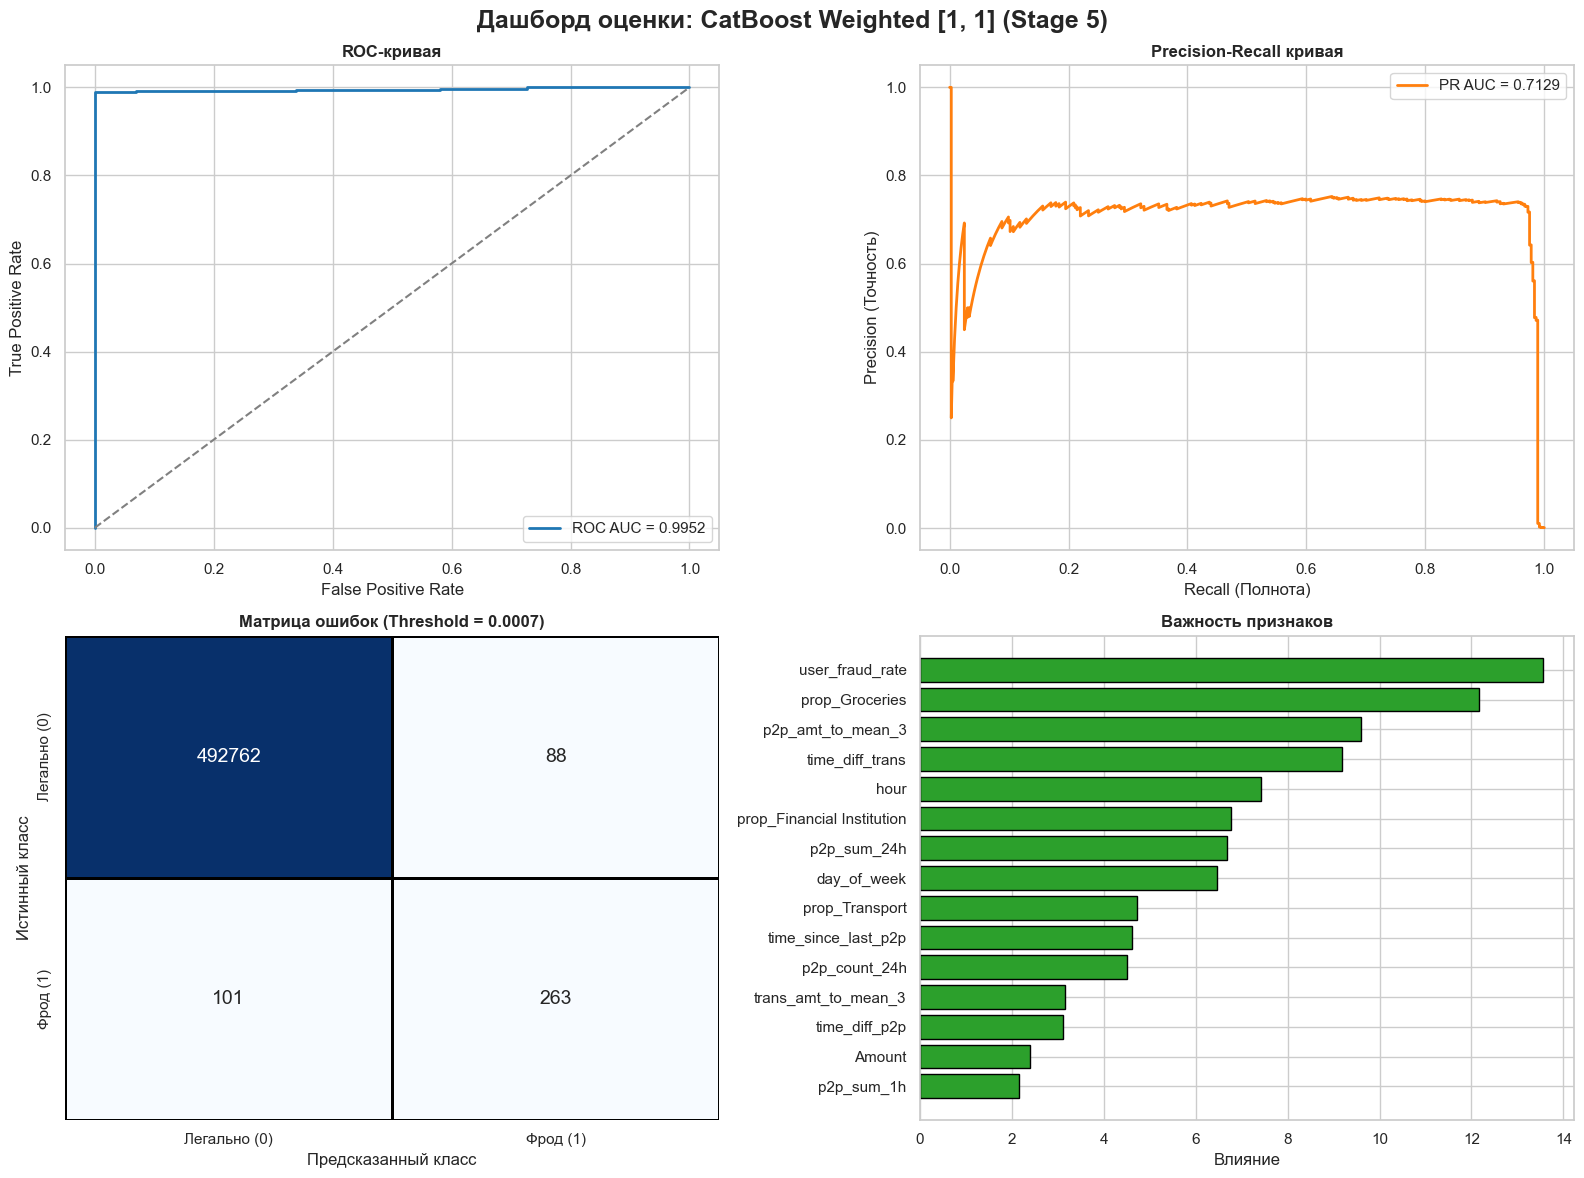

In [84]:
precisions_w, recalls_w, thresholds_w = precision_recall_curve(y_test, y_probs_weights)
valid_w = np.where(recalls_w >= 0.70)[0]
optimal_threshold_w = thresholds_w[valid_w[np.argmax(precisions_w[valid_w])]] if len(valid_w) > 0 else 0.5

plot_any_model_evaluation(
    y_true=y_test, 
    y_pred_proba=y_probs_weights, 
    title_name="CatBoost Weighted [1, 1] (Stage 5)", 
    threshold=optimal_threshold_w,
    eval_model=best_cb_weights,
    X_train_df=X_train
)

ЭТАП 5: АНСАМБЛЬ (Блендинг оптимизированных CatBoost и LogReg)

Сверх-ансамбль (0.6 CB_opt + 0.4 LR_opt) ROC-AUC: 0.9953
Сверх-ансамбль (0.6 CB_opt + 0.4 LR_opt) PR-AUC:  0.7240

--- БИЗНЕС-МЕТРИКИ СВЕРХ-АНСАМБЛЯ ---
Оптимальный порог: 0.3988
Precision (Точность): 0.7200
Recall (Полнота):     0.9890


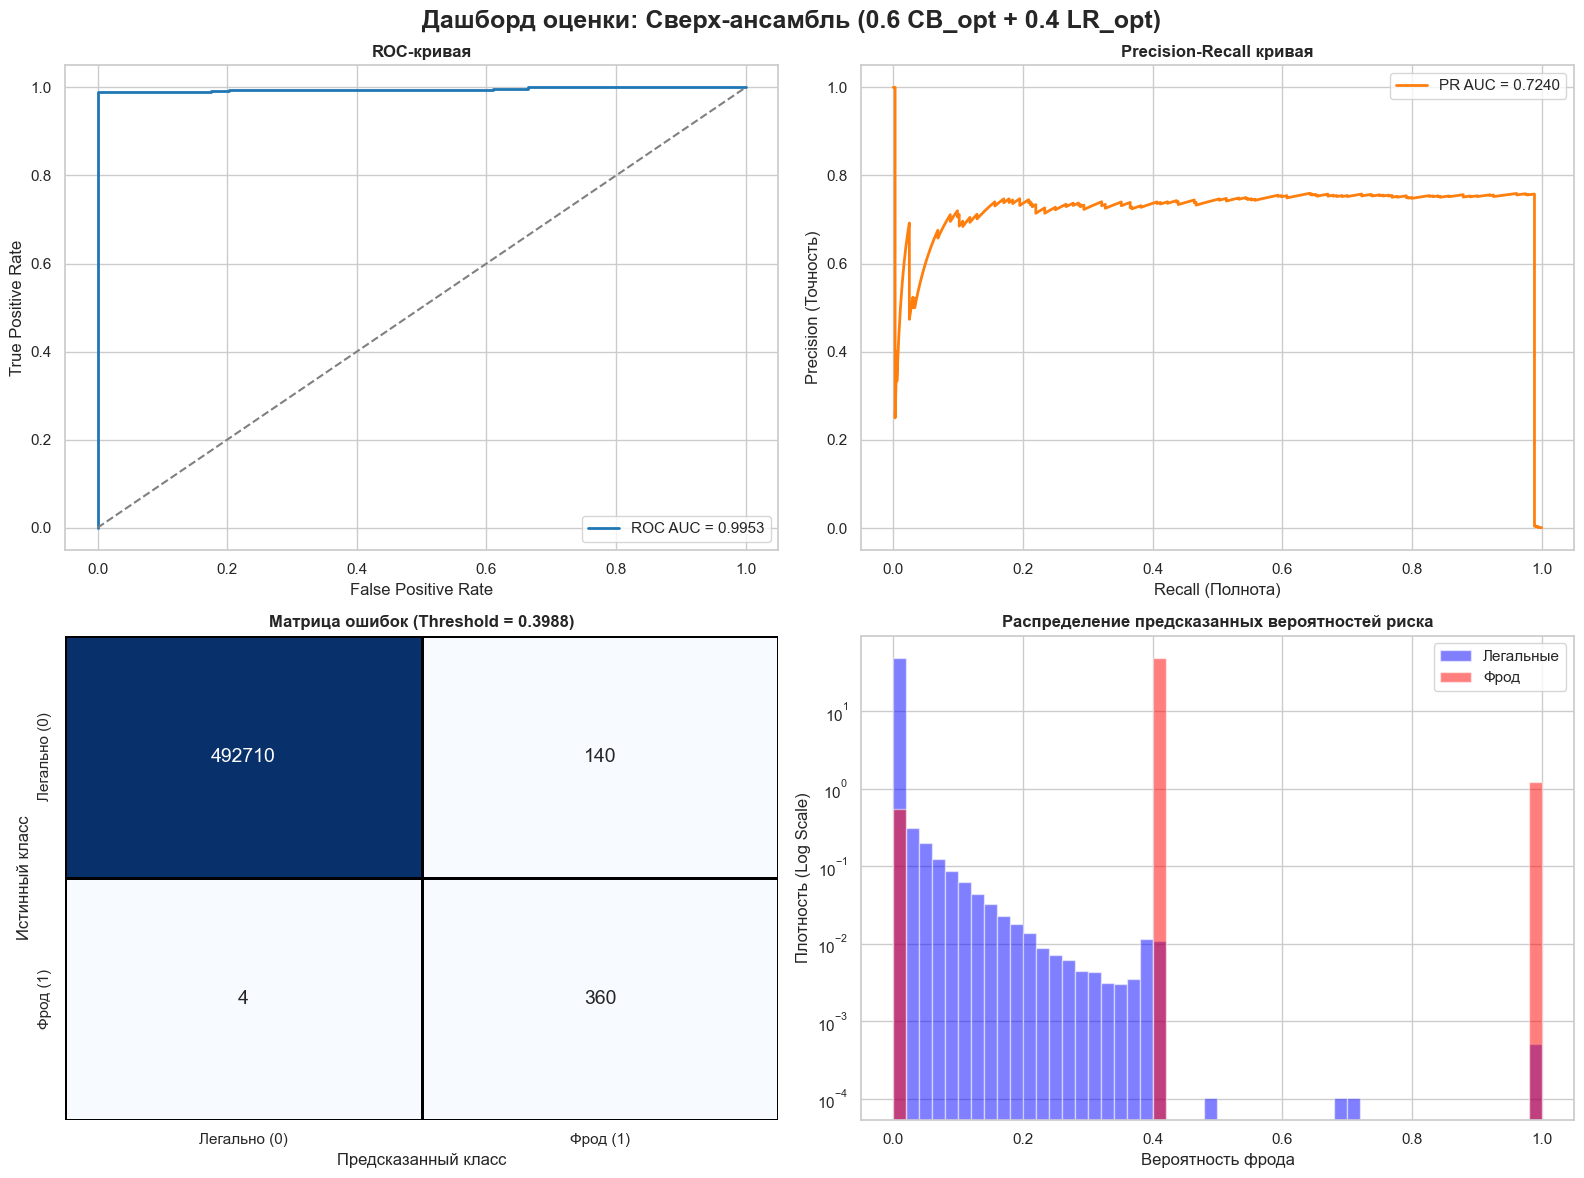

In [86]:
print("ЭТАП 5: АНСАМБЛЬ (Блендинг оптимизированных CatBoost и LogReg)")

# y_probs_weights -> предсказания CatBoost после тонкой настройки весов (Этап 5)
# y_probs_lr_best  -> предсказания лучшей LogReg (Этап 1)

# Веса смешивания (60% на улучшенный бустинг, 40% на стабильную регрессию)
w_cb_opt = 0.60
w_lr_opt = 0.40

# Смешиваем вероятности
y_probs_tuned_blend = (y_probs_weights * w_cb_opt) + (y_probs_lr_best * w_lr_opt)

tuned_blend_roc_auc = roc_auc_score(y_test, y_probs_tuned_blend)
tuned_blend_ap = average_precision_score(y_test, y_probs_tuned_blend)

print(f"\nСверх-ансамбль ({w_cb_opt} CB_opt + {w_lr_opt} LR_opt) ROC-AUC: {tuned_blend_roc_auc:.4f}")
print(f"Сверх-ансамбль ({w_cb_opt} CB_opt + {w_lr_opt} LR_opt) PR-AUC:  {tuned_blend_ap:.4f}")

# --- ПОДБОР ПОРОГА (Максимизируем Recall при Precision >= 72%) ---
MIN_PRECISION = 0.72 
precisions_tb, recalls_tb, thresholds_tb = precision_recall_curve(y_test, y_probs_tuned_blend)

valid_tb = np.where(precisions_tb >= MIN_PRECISION)[0]

if len(valid_tb) > 0:
    best_idx_tb = valid_tb[np.argmax(recalls_tb[valid_tb])]
    
    optimal_threshold_tb = thresholds_tb[min(best_idx_tb, len(thresholds_tb) - 1)]
    
    print("\n--- БИЗНЕС-МЕТРИКИ СВЕРХ-АНСАМБЛЯ ---")
    print(f"Оптимальный порог: {optimal_threshold_tb:.4f}")
    print(f"Precision (Точность): {precisions_tb[best_idx_tb]:.4f}")
    print(f"Recall (Полнота):     {recalls_tb[best_idx_tb]:.4f}")
else:
    optimal_threshold_tb = 0.5
    print(f"\nМодель не смогла достичь Precision >= {MIN_PRECISION}. Использован дефолтный порог 0.5")

plot_any_model_evaluation(
    y_true=y_test, 
    y_pred_proba=y_probs_tuned_blend, 
    title_name=f"Сверх-ансамбль ({w_cb_opt} CB_opt + {w_lr_opt} LR_opt)", 
    threshold=optimal_threshold_tb
)

In [85]:
print("\nЭТАП 6: ДВУХСТАДИЙНАЯ ФИЛЬТРАЦИЯ (Каскад моделей)")

# --- СТАДИЯ 1: Базовая фильтрация ---
model_stage_1 = best_cb_weights 

y_train_probs_s1 = model_stage_1.predict_proba(X_train)[:, 1]

gray_zone_mask = (y_train_probs_s1 > 0.05) & (y_train_probs_s1 < 0.80)

X_train_gray = X_train[gray_zone_mask]
y_train_gray = y_train[gray_zone_mask]

print(f"Размер исходного трейна: {len(X_train)} строк")
print(f"Размер серой зоны для Стадии 2: {len(X_train_gray)} строк")

# --- СТАДИЯ 2: Микро-модель для серой зоны ---
if len(X_train_gray) > 1000:
    model_stage_2 = CatBoostClassifier(
        depth=6, 
        iterations=500,
        random_state=42, 
        verbose=0,
        task_type='GPU',
        devices='0'
    )
    model_stage_2.fit(X_train_gray, y_train_gray)
    
    y_test_probs_s1 = model_stage_1.predict_proba(X_test)[:, 1]
    y_test_probs_final = y_test_probs_s1.copy()
    
    test_gray_mask = (y_test_probs_s1 > 0.05) & (y_test_probs_s1 < 0.80)
    X_test_gray = X_test[test_gray_mask]
    
    if len(X_test_gray) > 0:
        y_test_probs_final[test_gray_mask] = model_stage_2.predict_proba(X_test_gray)[:, 1]

    print("\n--- ИТОГОВЫЕ МЕТРИКИ КАСКАДА ---")
    print(f"Каскад ROC-AUC: {roc_auc_score(y_test, y_test_probs_final):.4f}")
    print(f"Каскад PR-AUC:  {average_precision_score(y_test, y_test_probs_final):.4f}")
    
    precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, y_test_probs_final)
    valid_c = np.where(recalls_c >= 0.70)[0]

    if len(valid_c) > 0:
        best_idx_c = valid_c[np.argmax(precisions_c[valid_c])]
        print("\n--- БИЗНЕС-МЕТРИКИ КАСКАДА ---")
        print(f"Оптимальный порог: {thresholds_c[best_idx_c]:.4f}")
        print(f"Precision:         {precisions_c[best_idx_c]:.4f}")
        print(f"Recall:            {recalls_c[best_idx_c]:.4f}")
else:
    print("В серой зоне слишком мало данных для обучения второй стадии.")


ЭТАП 6: ДВУХСТАДИЙНАЯ ФИЛЬТРАЦИЯ (Каскад моделей)
Размер исходного трейна: 1578283 строк
Размер серой зоны для Стадии 2: 21 строк
В серой зоне слишком мало данных для обучения второй стадии.


In [88]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# 1. Сохраняем словари Bayesian Target Encoding для инференса
te_maps = {
    'global_mean': global_mean,
    'recipient_map': smoothed_rec.to_dict(),
    'user_map': smoothed_user.to_dict()
}
joblib.dump(te_maps, '../models/bayesian_te_maps.pkl')

# 2. Сохраняем предобработчик и саму логистическую регрессию (весь Pipeline)
joblib.dump(best_lr, '../models/logistic_regression_pipeline.pkl')

# 3. Сохраняем обученный CatBoost (используем внутренний быстрый формат CBM)
best_cb_weights.save_model('../models/catboost_fraud_model_weights.cbm')

print("Вся экосистема ансамбля успешно сохранена в '../models/'!")

Вся экосистема ансамбля успешно сохранена в '../models/'!
